# Training Demo 01: Mouse Embryogenesis Subset Training


This notebook shows how to train **Navigo** on a sampled mouse embryogenesis subset using the standard repository training script, then inspect optimization and alignment metrics from the run.

The tutorial uses a subset on purpose. Training on the full embryogenesis atlas is much more time-consuming, so this notebook uses a smaller sampled dataset to demonstrate the **training workflow end to end** in a way that is practical to run interactively.

In this notebook you will:
1. Sample **10,000 cells** across **10 training time points** from the full embryogenesis atlas.
2. Train Navigo end to end with `submission/main_navigo.py` on **GPU**.
3. Review **loss curves** and **round-wise EMD metrics** collected during training.
4. Evaluate held-out intermediate time points with **EMD distance metrics**.



## Data Download

To run this notebook, download the tutorial data and checkpoint bundles from Google Drive:

- Tutorial data bundle: [data.tar.gz](https://drive.google.com/file/d/1WelqIkm2y2TrQRMxYKprVp5evbwRk0_S/view?usp=sharing)
- Tutorial checkpoint bundle: [checkpoints.tar.gz](https://drive.google.com/file/d/1lPOn01Z87zZ9q9vCfszEOagoOGdiyUiV/view?usp=sharing)

From the repository root:

```bash
curl -L 'https://drive.usercontent.google.com/download?id=1WelqIkm2y2TrQRMxYKprVp5evbwRk0_S&export=download&confirm=t' -o data.tar.gz
curl -L 'https://drive.usercontent.google.com/download?id=1lPOn01Z87zZ9q9vCfszEOagoOGdiyUiV&export=download&confirm=t' -o checkpoints.tar.gz
tar -xzf data.tar.gz
tar -xzf checkpoints.tar.gz
```

These notebooks assume top-level `data/` and `checkpoints/` directories in the repository root.


Import required packages and set deterministic seeds.


In [1]:
import json
import os
os.environ.setdefault('NUMBA_CACHE_DIR', '/tmp/numba_cache')
import random
import re
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from scipy import sparse

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Seed set to {SEED}')



Seed set to 42


Define shared helpers for path resolution and dense conversion.


In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'docs' / 'tutorials').exists() and (p / 'navigo').exists():
            return p
    raise RuntimeError('Could not locate repository root containing docs/tutorials and the navigo package.')


def to_dense(x):
    return x.toarray() if sparse.issparse(x) else np.asarray(x)


def parse_training_log(log_path: Path) -> pd.DataFrame:
    if not log_path.exists():
        return pd.DataFrame()

    records = []
    text = log_path.read_text(encoding='utf-8', errors='ignore').replace('\r', '\n')
    for line in text.splitlines():
        if 'all_loss:' not in line:
            continue
        pairs = re.findall(r'([A-Za-z0-9_]+):\s*([0-9.]+)', line)
        if not pairs:
            continue
        row = {key: float(value) for key, value in pairs}
        row['train_step'] = len(records) + 1
        records.append(row)
    return pd.DataFrame(records)


def summarize_round_scores(score_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    round_rows = []
    final_detail_df = pd.DataFrame()

    for score_path in sorted(score_dir.glob('score_*.json')):
        round_idx = int(score_path.stem.split('_')[-1]) + 1
        score_payload = json.loads(score_path.read_text())
        detail_rows = []
        for time_str, metrics in sorted(score_payload.items(), key=lambda item: float(item[0])):
            baseline = float(metrics['baseline'])
            prediction = float(metrics['prediction'])
            detail_rows.append(
                {
                    'round': round_idx,
                    'time': float(time_str),
                    'prediction_emd': prediction,
                    'baseline_emd': baseline,
                    'improvement': baseline - prediction,
                    'relative_improvement': (baseline - prediction) / baseline if baseline > 0 else 0.0,
                }
            )
        detail_df = pd.DataFrame(detail_rows).sort_values('time').reset_index(drop=True)
        if detail_df.empty:
            continue
        round_rows.append(
            {
                'round': round_idx,
                'mean_prediction_emd': detail_df['prediction_emd'].mean(),
                'mean_baseline_emd': detail_df['baseline_emd'].mean(),
                'mean_improvement': detail_df['improvement'].mean(),
                'mean_relative_improvement': detail_df['relative_improvement'].mean(),
            }
        )
        final_detail_df = detail_df

    return pd.DataFrame(round_rows), final_detail_df


Set paths and runtime configuration for the training demo.


In [3]:
repo_root = find_repo_root(Path.cwd().resolve())
tutorials_root = repo_root / 'docs' / 'tutorials'
notebook_dir = tutorials_root / 'notebooks' / 'training_demo'
output_root = tutorials_root / 'outputs' / 'training_demo'

data_root = repo_root / 'data' / 'interpolation'
full_data = data_root / 'mouse_embryogenesis_aggregated_full_hvg_4000.h5ad'
subset_data = output_root / '00_subset' / 'mouse_embryogenesis_training_subset_10k_10tp.h5ad'
subset_summary = subset_data.with_suffix('.json')
subset_overview_png = output_root / '00_subset' / 'subset_sampling_overview.png'

REUSE_EXISTING = True
RUN_SUBSET_SAMPLING = True
RUN_TRAINING = True
RUN_VALIDATION = True
SUBSET_TOTAL_CELLS = 10000
SUBSET_NUM_TIMEPOINTS = 10
TRAIN_ROUNDS = 3
TRAIN_STEPS = 20
TRAIN_BATCH_SIZE = 16
TRAIN_DEVICE = 'cuda'
TRAIN_TAG = f'gpu0_bs{TRAIN_BATCH_SIZE}_r{TRAIN_ROUNDS}_s{TRAIN_STEPS}_subset10k'

training_output_dir = output_root / f'01_training_run_{TRAIN_TAG}'
training_log_path = training_output_dir / 'training_stdout.log'
metrics_plot_png = output_root / '03_notebook_figures' / f'training_metrics_summary_{TRAIN_TAG}.png'

validation_script = repo_root / 'navigo' / 'training_demo_validate_intermediate_metrics.py'
validation_output_dir = output_root / f'02_validation_metrics_{TRAIN_TAG}'
validation_metrics_png = validation_output_dir / 'heldout_intermediate_metrics.png'
validation_metrics_csv = validation_output_dir / 'heldout_intermediate_metrics.csv'
validation_summary_json = validation_output_dir / 'heldout_intermediate_metrics_summary.json'

sample_script = repo_root / 'navigo' / 'training_demo_sample_training_subset.py'
train_script = repo_root / 'submission' / 'main_navigo.py'

output_root.mkdir(parents=True, exist_ok=True)
metrics_plot_png.parent.mkdir(parents=True, exist_ok=True)

print(f'Subset dataset: {subset_data.relative_to(repo_root)}')
print(f'Training output dir: {training_output_dir.relative_to(repo_root)}')
print(f'Validation output dir: {validation_output_dir.relative_to(repo_root)}')
print(f'Training device: {TRAIN_DEVICE}')
print(f'Rounds: {TRAIN_ROUNDS} | Train steps per round: {TRAIN_STEPS} | Batch size: {TRAIN_BATCH_SIZE}')



Subset dataset: docs/tutorials/outputs/training_demo/00_subset/mouse_embryogenesis_training_subset_10k_10tp.h5ad
Training output dir: docs/tutorials/outputs/training_demo/01_training_run_gpu0_bs16_r3_s20_subset10k
Validation output dir: docs/tutorials/outputs/training_demo/02_validation_metrics_gpu0_bs16_r3_s20_subset10k
Training device: cuda
Rounds: 3 | Train steps per round: 20 | Batch size: 16


## Step 1: Sample a 10k-cell, 10-timepoint training subset


In [4]:
if RUN_SUBSET_SAMPLING:
    if REUSE_EXISTING and subset_data.exists() and subset_summary.exists():
        print('Reusing existing sampled subset.')
    else:
        sample_cmd = [
            sys.executable,
            str(sample_script),
            '--input-data', str(full_data),
            '--output-data', str(subset_data),
            '--total-cells', str(SUBSET_TOTAL_CELLS),
            '--num-timepoints', str(SUBSET_NUM_TIMEPOINTS),
            '--seed', str(SEED),
            '--overwrite',
        ]
        subprocess.run(sample_cmd, check=True, cwd=repo_root)

subset_info = json.loads(subset_summary.read_text())
source_dataset_display = str(Path(subset_info['source_dataset']))

print(f'Source dataset: {source_dataset_display}')
print(f"Total sampled cells: {subset_info['total_cells']}")
print(f"Training time points: {subset_info['num_timepoints']}")
print(f"Sampling seed: {subset_info['seed']}")


Reusing existing sampled subset.
Source dataset: /workspace/fanyimin/Navigo-release/data/interpolation/mouse_embryogenesis_aggregated_full_hvg_4000.h5ad
Total sampled cells: 10000
Training time points: 10
Sampling seed: 42


## Step 2: Train Navigo with the repository training script
This uses the standard `submission/main_navigo.py` entrypoint on **GPU** with a compact tutorial schedule for the sampled subset.


In [5]:
train_env = dict(os.environ)
train_env['PYTHONPATH'] = str(repo_root) if not train_env.get('PYTHONPATH') else f"{repo_root}:{train_env['PYTHONPATH']}"

checkpoint_path = training_output_dir / f'checkpoint-{TRAIN_ROUNDS}.pth'
need_training_run = not (
    REUSE_EXISTING
    and checkpoint_path.exists()
    and training_log_path.exists()
    and len(list(training_output_dir.glob('score_*.json'))) == TRAIN_ROUNDS
)

if RUN_TRAINING:
    if need_training_run:
        training_output_dir.mkdir(parents=True, exist_ok=True)
        train_cmd = [
            sys.executable,
            str(train_script),
            '--input_data', str(subset_data),
            '--output_dir', str(training_output_dir),
            '--rounds', str(TRAIN_ROUNDS),
            '--train_steps', str(TRAIN_STEPS),
            '--batch_size', str(TRAIN_BATCH_SIZE),
            '--save_every', '1',
            '--device', TRAIN_DEVICE,
        ]
        proc = subprocess.run(
            train_cmd,
            check=True,
            cwd=repo_root,
            env=train_env,
            capture_output=True,
            text=True,
        )
        training_log_path.write_text((proc.stdout or '') + '\n' + (proc.stderr or ''), encoding='utf-8')
    else:
        print('Reusing existing training outputs.')

loss_df = parse_training_log(training_log_path)
checkpoint_names = [p.name for p in sorted(training_output_dir.glob('checkpoint-*.pth'))]
print(f'Parsed {len(loss_df)} logged training steps.')
print(f'Found {len(checkpoint_names)} checkpoints.')


Reusing existing training outputs.
Parsed 60 logged training steps.
Found 3 checkpoints.


## Step 3: Review loss curves and alignment metrics


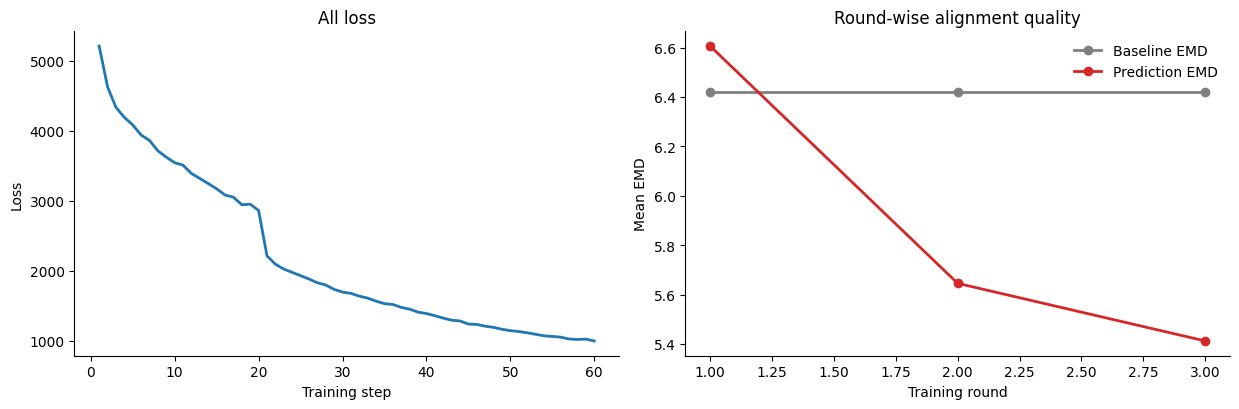

Saved training summary figure: docs/tutorials/outputs/training_demo/03_notebook_figures/training_metrics_summary_gpu0_bs16_r3_s20_subset10k.png


In [6]:
if loss_df.empty:
    raise ValueError(f'No loss history could be parsed from {training_log_path}')

round_df, final_score_df = summarize_round_scores(training_output_dir)
if round_df.empty:
    raise ValueError(f'No round score files were found in {training_output_dir}')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].plot(loss_df['train_step'], loss_df['all_loss'], color='#1f77b4', linewidth=2)
axes[0].set_xlabel('Training step')
axes[0].set_ylabel('Loss')
axes[0].set_title('All loss')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(round_df['round'], round_df['mean_baseline_emd'], marker='o', label='Baseline EMD', color='#7f7f7f', linewidth=2)
axes[1].plot(round_df['round'], round_df['mean_prediction_emd'], marker='o', label='Prediction EMD', color='#d62728', linewidth=2)
axes[1].set_xlabel('Training round')
axes[1].set_ylabel('Mean EMD')
axes[1].set_title('Round-wise alignment quality')
axes[1].legend(frameon=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(metrics_plot_png, dpi=220, bbox_inches='tight')
plt.show()

print(f'Saved training summary figure: {metrics_plot_png.relative_to(repo_root)}')



## Step 4: Validate held-out intermediate timepoints with EMD distance metrics

Run the held-out validation and compare three EMD distances at each intermediate timepoint: `prediction vs ground truth`, `start vs ground truth`, and `end anchor vs ground truth`.


Reusing existing validation outputs.
Mean EMD distances: prediction=5.3908 start=5.9676 end=6.0017
Mean improvements: prediction_vs_start=0.5767 prediction_vs_end=0.6109
Held-out intermediate timepoints: 33


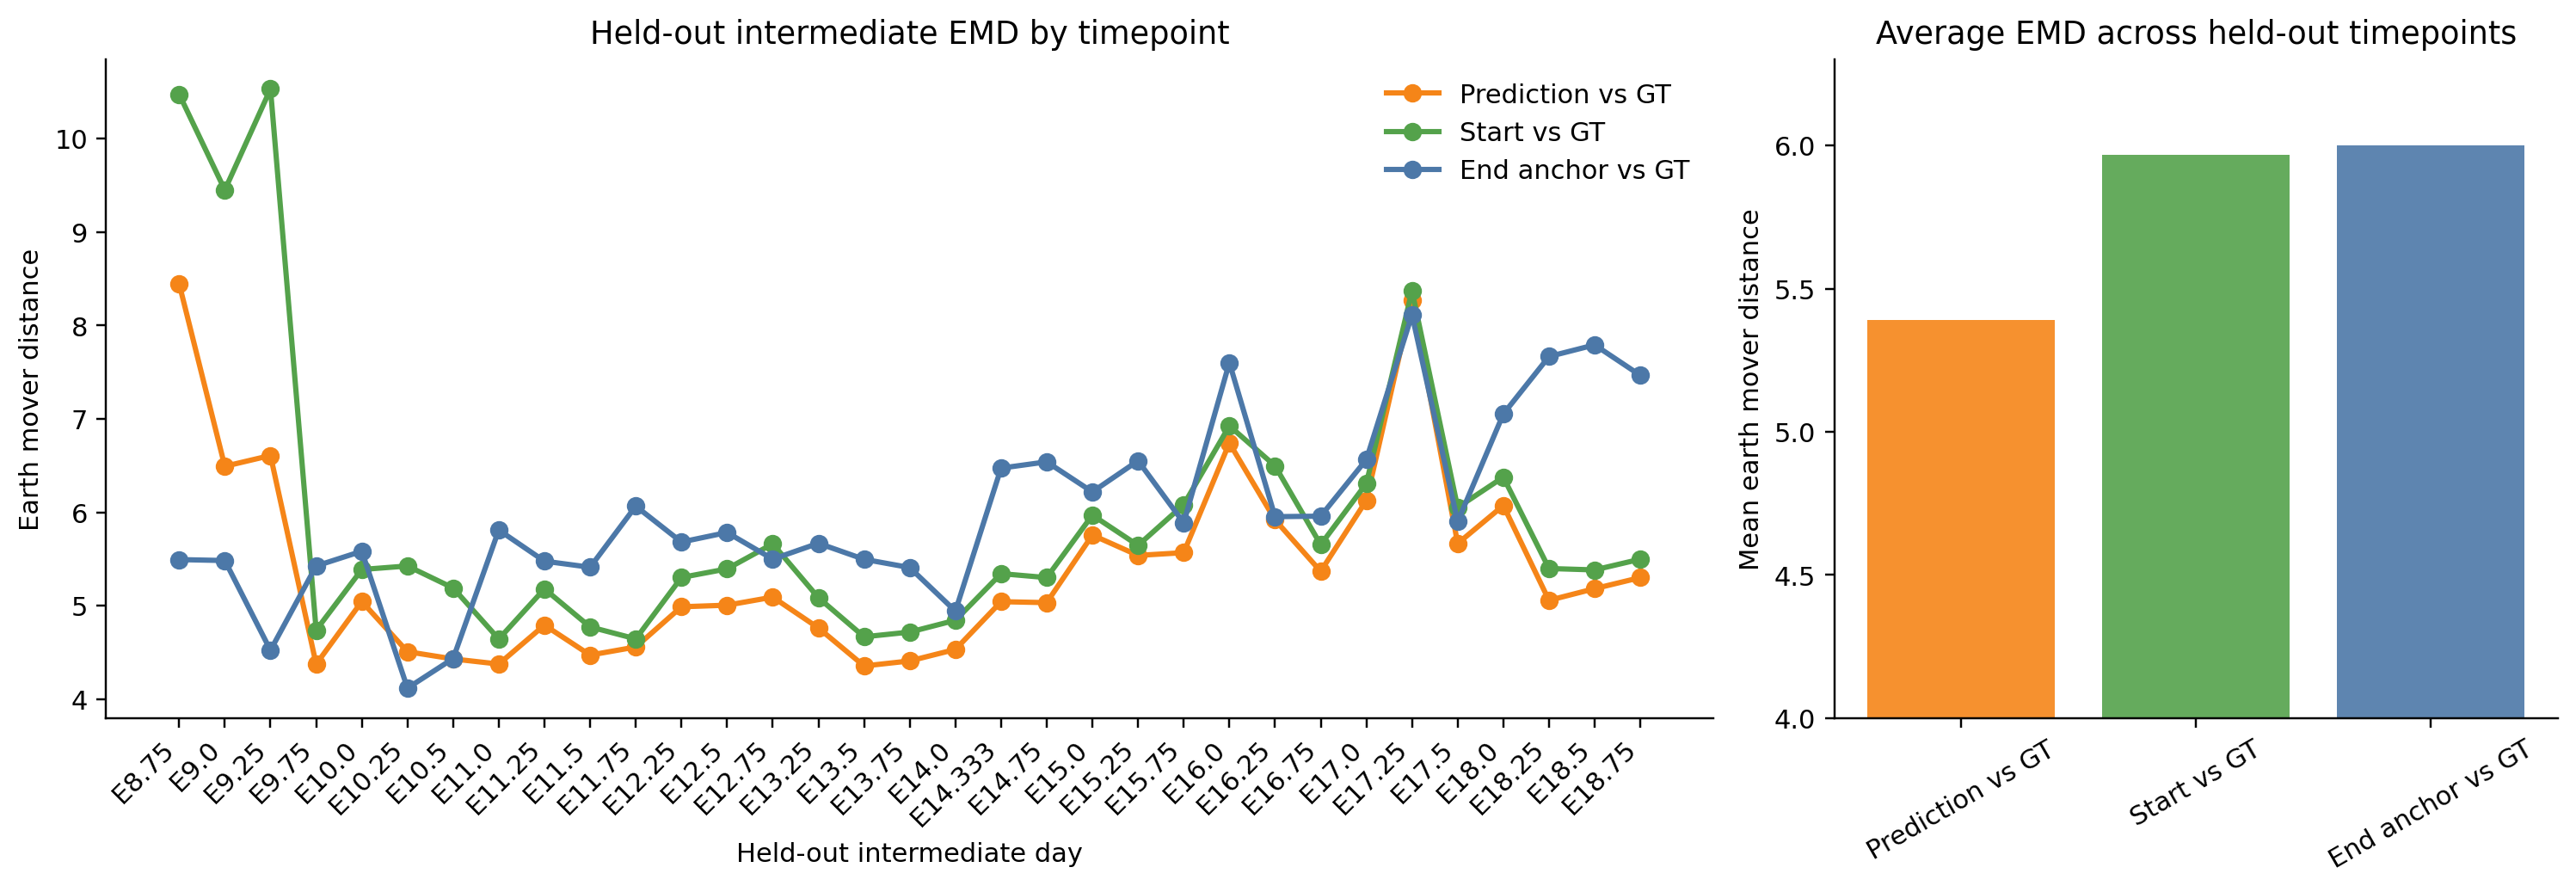

In [7]:
val_env = dict(os.environ)
val_env['PYTHONPATH'] = str(repo_root) if not val_env.get('PYTHONPATH') else f"{repo_root}:{val_env['PYTHONPATH']}"

checkpoint_path = training_output_dir / f'checkpoint-{TRAIN_ROUNDS}.pth'
need_validation_run = not (
    REUSE_EXISTING
    and validation_metrics_png.exists()
    and validation_metrics_csv.exists()
    and validation_summary_json.exists()
)

if RUN_VALIDATION:
    if need_validation_run:
        validation_output_dir.mkdir(parents=True, exist_ok=True)
        validation_cmd = [
            sys.executable,
            str(validation_script),
            '--subset-data', str(subset_data),
            '--full-data', str(full_data),
            '--checkpoint', str(checkpoint_path),
            '--output-dir', str(validation_output_dir),
            '--hidden-1', '5012',
            '--hidden-2', '5012',
            '--flow-steps', '10',
            '--integration-steps', '25',
            '--max-cells-per-group', '300',
            '--seed', str(SEED),
            '--device', 'auto',
        ]
        subprocess.run(validation_cmd, check=True, cwd=repo_root, env=val_env)
    else:
        print('Reusing existing validation outputs.')

validation_summary = json.loads(validation_summary_json.read_text())
validation_df = pd.read_csv(validation_metrics_csv)

print(
    'Mean EMD distances:',
    f"prediction={validation_summary['mean_prediction_emd']:.4f}",
    f"start={validation_summary['mean_start_emd']:.4f}",
    f"end={validation_summary['mean_end_anchor_emd']:.4f}",
)
print(
    'Mean improvements:',
    f"prediction_vs_start={validation_summary['mean_prediction_vs_start_improvement']:.4f}",
    f"prediction_vs_end={validation_summary['mean_prediction_vs_end_improvement']:.4f}",
)
print(f"Held-out intermediate timepoints: {len(validation_df)}")
display(Image(filename=str(validation_metrics_png)))



## Notes

- The subset is only for tutorial-scale training and evaluation.
- The training run uses the same repository trainer as the full workflow.
- This notebook uses the tutorial training schedule: `--rounds 3 --train_steps 20 --batch_size 16`.
- The round-wise EMD scores come from the alignment evaluation written by `submission/main_navigo.py` after each training round.
- The held-out validation plot compares EMD distances from `prediction`, `start`, and `end anchor` to ground truth. 

